In [43]:
# !pip install aiomoex
# !pip install tinkoff-investments
# !pip install yfinance

In [44]:
# !pip install git+https://github.com/tinkoff/invest-python.git --no-deps
# !pip install tensorflow==2.15.0 scikit-learn matplotlib pandas
# !pip install cachetools deprecation python-dateutil
# Устанавливаем конкретную версию cachetools, которую просит Тинькофф
# !pip install "cachetools>=5.2.0,<6.0.0"
# !pip install dotenv
# !pip install fastparquet

# !pip uninstall -y pandas pyarrow
# !pip install "pandas>=2.0.0" "pyarrow>=11.0.0"
# !pip install seaborn

In [45]:
# !pip freeze > requirements.txt

In [101]:
from tinkoff.invest import Client, AsyncClient, CandleInterval, SecurityTradingStatus, InstrumentStatus
from tinkoff.invest.services import InstrumentsService
from tinkoff.invest.utils import quotation_to_decimal, now
from tinkoff.invest.caching.instruments_cache.instruments_cache import InstrumentsCache

from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import pyarrow
import pandas as pd
from pandas.tseries.offsets import DateOffset
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
# import asyncio
import math

import time
from datetime import datetime, timezone, timedelta

from pathlib import Path
from typing import Dict, List, Tuple, Optional

from dotenv import load_dotenv

import warnings
warnings.filterwarnings("ignore")

In [47]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

In [48]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

In [49]:
load_dotenv()

TOKEN = os.getenv("TOKEN")

In [50]:
TRAIN_MONTHS = 48  # Длительность обучения
TEST_MONTHS = 1    # Как часто переобучаем модель и тестируем (например, раз в месяц)
WINDOW_SIZE = 24   # Размер входного окна (24 свечи = 2 часа для 5-мин)
ALPHA = 2       # Порог волатильности для таргета
LEARNING_RATE = 0.0001
CONFIDENCE_THRESHOLD = 0.7

In [51]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Очищает данные от пропусков и нулевых значений.
    """
    df = df.copy()
    
    # 1. Заменяем чистые нули на NaN (в цене Close/Open нулей быть не может)
    # Делаем это только для колонок с ценами
    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    for col in cols_to_fix:
        df[col] = df[col].replace(0, pd.NA)
    
    # 2. Сортируем по времени (важно для правильного заполнения "вперед")
    df = df.sort_values("DateTime")
    
    # 3. Forward Fill: заполняем пропуски последним известным значением
    df[cols_to_fix] = df[cols_to_fix].ffill()
    
    # 4. Backward Fill: на случай, если пропуски в самых первых строках
    df[cols_to_fix] = df[cols_to_fix].bfill()
    
    # 5. Обработка объема (Volume)
    # Для объема пропуски лучше заменять на 0, так как сделок просто не было
    df['Volume'] = df['Volume'].fillna(0)
    
    return df

In [52]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str = "5min") -> pd.DataFrame:
    """
    Вставляет пропущенные временные интервалы (строки), которых нет в данных.
    """
    # Маппинг для метода resample
    resample_map = {
        "5min": "5min", "15min": "15min", "1hour": "h", "1day": "D"
    }
    freq = resample_map.get(interval_name, "5min")
    
    df = df.set_index("DateTime").sort_index()
    
    # Создаем полный индекс без дыр от начала до конца
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    
    # Переиндексируем (появятся строки с NaN там, где были дыры)
    df = df.reindex(full_range)
    df.index.name = "DateTime"
    
    # Заполняем пустоты
    df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].ffill()
    df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

In [53]:
def add_technical_indicators(df: pd.DataFrame, 
                             sma_periods: list = [20, 50, 200],
                             ema_periods: list = [12, 26],
                             rsi_period: int = 14,
                             macd_fast: int = 12,
                             macd_slow: int = 26,
                             macd_signal: int = 9,
                             bb_period: int = 20,
                             cci_period: int = 20,
                             adx_period: int = 14,
                             roc_period: int = 12,
                             cmf_period: int = 20) -> pd.DataFrame:
    """
    Добавляет полный набор технических индикаторов (Lagging, Leading, Neutral).
    """
    df = df.copy()
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']
    
    # --- LAGGING INDICATORS ---
    
    # SMA & EMA
    for period in sma_periods:
        df[f'SMA_{period}'] = close.rolling(window=period).mean()
    for period in ema_periods:
        df[f'EMA_{period}'] = close.ewm(span=period, adjust=False).mean()
    
    # MACD
    ema_f = close.ewm(span=macd_fast, adjust=False).mean()
    ema_s = close.ewm(span=macd_slow, adjust=False).mean()
    df['MACD'] = ema_f - ema_s
    df['MACD_Signal'] = df['MACD'].ewm(span=macd_signal, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    
    # Bollinger Bands
    sma_bb = close.rolling(window=bb_period).mean()
    std_bb = close.rolling(window=bb_period).std()
    df['BB_Upper'] = sma_bb + (2 * std_bb)
    df['BB_Lower'] = sma_bb - (2 * std_bb)
    
    # --- LEADING INDICATORS ---
    
    # RSI
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_period).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # CCI (Commodity Channel Index)
    tp = (high + low + close) / 3
    sma_tp = tp.rolling(window=cci_period).mean()
    mad_tp = tp.rolling(window=cci_period).apply(lambda x: np.abs(x - x.mean()).mean())
    df['CCI'] = (tp - sma_tp) / (0.015 * mad_tp)
    
    # VWAP (Volume Weighted Average Price)
    # Считается накопительно, если данные внутри дня, или скользящим окном
    df['VWAP'] = (volume * (high + low + close) / 3).cumsum() / volume.cumsum()
    
    # OBV (On-Balance Volume)
    df['OBV'] = (np.sign(close.diff()) * volume).fillna(0).cumsum()
    
    # ADX (Average Directional Index)
    plus_dm = high.diff().where((high.diff() > low.diff().abs()) & (high.diff() > 0), 0)
    minus_dm = low.diff().abs().where((low.diff().abs() > high.diff()) & (low.diff().abs() > 0), 0)
    tr = pd.concat([high - low, (high - close.shift()).abs(), (low - close.shift()).abs()], axis=1).max(axis=1)
    atr = tr.rolling(window=adx_period).mean()
    plus_di = 100 * (plus_dm.rolling(window=adx_period).mean() / atr)
    minus_di = 100 * (minus_dm.rolling(window=adx_period).mean() / atr)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    df['ADX'] = dx.rolling(window=adx_period).mean()
    
    # ADL (Accumulation Distribution Line)
    mfm = ((close - low) - (high - close)) / (high - low)
    mfm = mfm.replace([np.inf, -np.inf], 0).fillna(0) # Защита от zero division если high==low
    df['ADL'] = (mfm * volume).cumsum()
    
    # CMF (Chaikin Money Flow)
    mfv = mfm * volume
    df['CMF'] = mfv.rolling(window=cmf_period).sum() / volume.rolling(window=cmf_period).sum()
    
    # --- NEUTRAL / MOMENTUM INDICATORS ---
    
    # ROC (Rate of Change)
    df['ROC'] = ((close - close.shift(roc_period)) / close.shift(roc_period)) * 100
    
    return df

In [54]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax') 
    ])
    
    # Использование legacy оптимизатора для ускорения на M1/M2/M3
    try:
        opt = optimizers.legacy.Adam(learning_rate=LEARNING_RATE)
        print("Используется оптимизатор legacy.Adam для Mac")
    except AttributeError:
        opt = optimizers.Adam(learning_rate=LEARNING_RATE)
        print("Используется стандартный Adam")

    model.compile(
        optimizer=opt, 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

In [55]:
def create_tensors(df, window_size=WINDOW_SIZE, alpha=ALPHA):
    """
    Создает X (тензоры для CNN) и y (таргеты по волатильности).
    """
    df = df.copy().sort_values("DateTime")
    
    # Расчет таргета
    returns = df['Close'].pct_change()
    volatility = returns.rolling(window=10).std()
    # Изменение цены через 24 свечи (2 часа для 5-мин интервала)
    future_change = (df['Close'].shift(-window_size) - df['Close']) / df['Close']
    
    conditions = [
        (future_change >= alpha * volatility), # Up (1)
        (future_change <= -alpha * volatility) # Down (2)
    ]
    df['Target'] = np.select(conditions, [1, 2], default=0) # Flat (0)
    
    # Фичи: OHLCV
    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    data_x = df[features].values
    data_y = df['Target'].values
    dates = df['DateTime'].values
    prices = df['Close'].values

    X, y, out_dates, out_prices = [], [], [], []

    for i in range(window_size, len(df) - window_size):
        window = data_x[i-window_size:i]
        
        # Локальная нормализация окна (Z-score) для стабильности CNN
        scaler = StandardScaler()
        norm_window = scaler.fit_transform(window)
        
        X.append(norm_window)
        y.append(data_y[i])
        out_dates.append(dates[i])
        out_prices.append(prices[i])

    return np.array(X), np.array(y), np.array(out_dates), np.array(out_prices)

In [56]:
def run_backtest_with_fine_tuning(df, confidence_threshold = CONFIDENCE_THRESHOLD):
    total_months = (df['DateTime'].max() - df['DateTime'].min()).days // 30
    if total_months < TRAIN_MONTHS + TEST_MONTHS:
        print(f"ВНИМАНИЕ: Недостаточно данных! Всего месяцев: {total_months}, нужно минимум: {TRAIN_MONTHS + TEST_MONTHS}")
    else:
        print(f"Данных достаточно. Обучение: {TRAIN_MONTHS} мес. Проверка составит примерно {total_months - TRAIN_MONTHS} мес.")
        
    # Используем более жесткие параметры при создании тензоров
    X_all, y_all, dates_all, prices_all = create_tensors(df, alpha=ALPHA) 
    dt_index = pd.to_datetime(dates_all)
    
    start_date = dt_index.min()
    current_test_start = start_date + DateOffset(months=TRAIN_MONTHS)
    
    model = build_model(input_shape=(WINDOW_SIZE, 5))
    
    initial_mask = (dt_index >= start_date) & (dt_index < current_test_start)
    model.fit(X_all[initial_mask], y_all[initial_mask], epochs=15, batch_size=32, verbose=1)
    
    all_preds = []
    confidence_threshold = CONFIDENCE_THRESHOLD # Фильтр "уверенности"

    while current_test_start < dt_index.max():
        test_end = current_test_start + DateOffset(months=TEST_MONTHS)
        test_mask = (dt_index >= current_test_start) & (dt_index < test_end)
        
        X_test, y_test = X_all[test_mask], y_all[test_mask]
        if len(X_test) == 0: break
            
        probs = model.predict(X_test, verbose=0)
        
        # ЛОГИКА ФИЛЬТРАЦИИ:
        # p[0] - Flat, p[1] - Buy, p[2] - Sell
        final_classes = []
        for p in probs:
            if p[1] > CONFIDENCE_THRESHOLD:
                final_classes.append(1)
            elif p[2] > CONFIDENCE_THRESHOLD:
                final_classes.append(2)
            else:
                final_classes.append(0) # Игнорируем неуверенные сигналы
        
        chunk_results = pd.DataFrame({
            'DateTime': dates_all[test_mask],
            'Price': prices_all[test_mask],
            'Actual': y_test,
            'Predicted': final_classes
        })
        all_preds.append(chunk_results)
        
        model.fit(X_test, y_test, epochs=1, batch_size=32, verbose=0)
        current_test_start = test_end

    return pd.concat(all_preds)

In [57]:
df_YDEX = pd.read_parquet('data/YDEX_5min.parquet')
df_YDEX = df_YDEX[df_YDEX['DateTime'] >= '2020-01-01']
df_YDEX = df_YDEX[df_YDEX['DateTime'] < '2026-01-01']
df_YDEX = fill_time_gaps(df_YDEX)
df_YDEX = clean_market_data(df_YDEX)

In [ ]:
class AnomalyDetector:
    """
    Класс для комплексного обнаружения и очистки аномалий в котировках финансовых инструментов.
    
    Реализует три уровня детекции:
        1. Структурная валидация (правила бизнес-логики OHLCV)
        2. Унивариантные статистические методы (Modified Z-score, IQR)
        3. Многомерный машинный подход (Isolation Forest)
    
    Используется на этапе предобработки данных перед генерацией признаков и обучением моделей глубокого обучения.
    """

    def __init__(self, z_threshold: float = 5, contamination: float = 0.005):
        """
        Args:
            z_threshold: Порог Modified Z-score для детекции ценовых спайков
            contamination: Ожидаемая доля аномалий для Isolation Forest (обычно 0.5–2%)
        """
        self.z_threshold = z_threshold
        self.contamination = contamination
        self.anomaly_log: List[Dict] = []

    def structural_validation(self, df: pd.DataFrame) -> List[Dict]:
        """Базовая структурная проверка данных по правилам рыночной микроструктуры."""
        issues = []
        df = df.copy()

        # 1. Отрицательные или нулевые цены
        for col in ['Open', 'High', 'Low', 'Close']:
            if col in df.columns:
                negative_mask = df[col] <= 0
                if negative_mask.any():
                    issues.append({
                        'type': 'negative_or_zero_price',
                        'column': col,
                        'count': negative_mask.sum(),
                        'dates': df.index[negative_mask].tolist()
                    })

        # 2. Нарушение логических соотношений OHLC
        if all(col in df.columns for col in ['Open', 'High', 'Low', 'Close']):
            # High должен быть максимумом
            high_invalid = df['High'] < df[['Open', 'Close']].max(axis=1)
            if high_invalid.any():
                issues.append({
                    'type': 'invalid_high',
                    'count': high_invalid.sum(),
                    'dates': df.index[high_invalid].tolist()
                })

            # Low должен быть минимумом
            low_invalid = df['Low'] > df[['Open', 'Close']].min(axis=1)
            if low_invalid.any():
                issues.append({
                    'type': 'invalid_low',
                    'count': low_invalid.sum(),
                    'dates': df.index[low_invalid].tolist()
                })

        # 3. Нулевые объёмы (может быть нормально, но фиксируем)
        if 'Volume' in df.columns:
            zero_volume = df['Volume'] == 0
            if zero_volume.any():
                issues.append({
                    'type': 'zero_volume',
                    'count': zero_volume.sum(),
                    'dates': df.index[zero_volume].tolist()
                })

        return issues

    def detect_price_spikes(self, df: pd.DataFrame, column: str = 'Close') -> pd.Series:
        """Детекция ценовых спайков с помощью Modified Z-score (робастный к выбросам)."""
        if column not in df.columns or len(df) < 10:
            return pd.Series(False, index=df.index)

        returns = np.log(df[column] / df[column].shift(1)).dropna()
        median = returns.median()
        mad = np.abs(returns - median).median()

        if mad == 0:
            return pd.Series(False, index=df.index)

        modified_z = 0.6745 * (returns - median) / mad
        is_anomaly = np.abs(modified_z) > self.z_threshold

        # Приводим к исходному индексу
        full_anomaly = pd.Series(False, index=df.index)
        full_anomaly.loc[is_anomaly.index] = is_anomaly
        return full_anomaly

    def detect_volume_anomalies(self, df: pd.DataFrame) -> pd.Series:
        """Детекция аномальных объёмов через метод межквартильного размаха (3×IQR)."""
        if 'Volume' not in df.columns or len(df) < 20:
            return pd.Series(False, index=df.index)

        q1 = df['Volume'].quantile(0.25)
        q3 = df['Volume'].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 3 * iqr
        upper_bound = q3 + 3 * iqr

        return (df['Volume'] < lower_bound) | (df['Volume'] > upper_bound)

    def detect_multivariate_anomalies(self, df: pd.DataFrame) -> pd.Series:
        """Многомерное детектирование аномалий с помощью Isolation Forest."""
        features = []
        if len(df) < 50:
            return pd.Series(False, index=df.index)

        # 1. Логарифмическая доходность
        if 'Close' in df.columns:
            ret = df['Close'].pct_change().fillna(0)
            features.append(ret.values.reshape(-1, 1))

        # 2. Волатильность (20-периодная)
        if 'Close' in df.columns:
            vol = df['Close'].pct_change().rolling(20).std().fillna(0)
            features.append(vol.values.reshape(-1, 1))

        # 3. Нормализованный объём
        if 'Volume' in df.columns:
            vol_norm = stats.zscore(df['Volume'], nan_policy='omit')
            vol_norm = np.nan_to_num(vol_norm, 0)
            features.append(vol_norm.reshape(-1, 1))

        # 4. Относительный диапазон свечи
        if all(col in df.columns for col in ['High', 'Low', 'Close']):
            rel_range = (df['High'] - df['Low']) / df['Close']
            features.append(rel_range.fillna(0).values.reshape(-1, 1))

        if len(features) < 2:
            return pd.Series(False, index=df.index)

        X = np.hstack(features)

        clf = IsolationForest(
            contamination=self.contamination,
            random_state=42,
            n_estimators=150,
            max_samples='auto'
        )
        predictions = clf.fit_predict(X)
        return pd.Series(predictions == -1, index=df.index)

    def comprehensive_check(self, df: pd.DataFrame, ticker: str = "UNKNOWN") -> Tuple[Dict, pd.Series]:
        """
        Комплексная проверка данных.
        Возвращает отчёт и маску всех обнаруженных аномалий.
        """
        report = {
            'ticker': ticker,
            'total_rows': len(df),
            'structural_issues': [],
            'price_anomalies': 0,
            'volume_anomalies': 0,
            'multivariate_anomalies': 0,
            'total_anomalies': 0,
            'anomaly_dates': []
        }

        # 1. Структурные проблемы
        report['structural_issues'] = self.structural_validation(df)

        # 2. Ценовые спайки
        price_mask = self.detect_price_spikes(df)
        report['price_anomalies'] = int(price_mask.sum())

        # 3. Аномалии объёма
        volume_mask = self.detect_volume_anomalies(df)
        report['volume_anomalies'] = int(volume_mask.sum())

        # 4. Многомерные аномалии
        multi_mask = self.detect_multivariate_anomalies(df)
        report['multivariate_anomalies'] = int(multi_mask.sum())

        # Объединяем все аномалии
        all_anomalies = price_mask | volume_mask | multi_mask
        report['total_anomalies'] = int(all_anomalies.sum())
        report['anomaly_dates'] = df.index[all_anomalies].tolist()

        self.anomaly_log.append(report)

        return report, all_anomalies

    def clean_data(self, df: pd.DataFrame, anomaly_mask: pd.Series, 
                   method: str = 'interpolate') -> pd.DataFrame:
        """
        Очистка данных от аномалий.
        
        method: 'interpolate' | 'forward_fill' | 'remove'
        """
        cleaned = df.copy()

        if method == 'interpolate':
            for col in ['Open', 'High', 'Low', 'Close']:
                if col in cleaned.columns:
                    cleaned.loc[anomaly_mask, col] = np.nan
                    cleaned[col] = cleaned[col].interpolate(method='time')
        elif method == 'forward_fill':
            for col in ['Open', 'High', 'Low', 'Close']:
                if col in cleaned.columns:
                    cleaned.loc[anomaly_mask, col] = np.nan
                    cleaned[col] = cleaned[col].ffill()
        elif method == 'remove':
            cleaned = cleaned[~anomaly_mask]

        # Обработка Volume отдельно (никогда не удаляем полностью)
        if 'Volume' in cleaned.columns:
            cleaned.loc[anomaly_mask, 'Volume'] = np.nan
            cleaned['Volume'] = cleaned['Volume'].ffill().fillna(0)

        return cleaned

    def visualize_anomalies(self, df: pd.DataFrame, anomaly_mask: pd.Series, 
                        ticker: str = "UNKNOWN"):
        """
        Визуализация аномалий с downsampling до ~5% для больших датасетов.
        Гарантирует быстрый рендеринг даже при 600k+ строках.
        """
        # Приводим данные к DatetimeIndex
        df = df.copy()
        if 'DateTime' in df.columns:
            df = df.set_index('DateTime')
        
        # Выравниваем маску по индексу
        if isinstance(anomaly_mask, pd.Series):
            anomaly_mask = anomaly_mask.reindex(df.index, fill_value=False)
        else:
            anomaly_mask = pd.Series(anomaly_mask, index=df.index, dtype=bool)

        # === Downsampling до ~5% ===
        n_original = len(df)
        target_points = int(n_original * 0.05)   # 5%
        
        if n_original > 200_000:
            step = max(1, n_original // target_points)
            print(f"   [INFO] Downsampling: {n_original:,} → {n_original//step:,} точек (~5%)")
            
            df_plot = df.iloc[::step].copy()
            mask_plot = anomaly_mask.iloc[::step]
        else:
            df_plot = df
            mask_plot = anomaly_mask

        # Создаём фигуру
        fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

        # 1. Ценовой ряд
        axes[0].plot(df_plot.index, df_plot['Close'], 
                    color='#1f77b4', linewidth=1.1, label='Close Price')
        if mask_plot.any():
            axes[0].scatter(df_plot.index[mask_plot], df_plot['Close'][mask_plot],
                            color='red', s=45, marker='x', linewidth=1.3, 
                            label='Anomalies', zorder=5)
        
        axes[0].set_title(f'{ticker} — Ценовой ряд с обнаруженными аномалиями', fontsize=13, pad=12)
        axes[0].set_ylabel('Цена', fontsize=11)
        axes[0].legend(loc='best')
        axes[0].grid(True, alpha=0.3)

        # 2. Доходности
        returns = df_plot['Close'].pct_change()
        axes[1].plot(df_plot.index, returns, 
                    color='#666666', linewidth=0.9, alpha=0.85)
        if mask_plot.any():
            axes[1].scatter(df_plot.index[mask_plot], returns[mask_plot],
                            color='red', s=45, marker='x', linewidth=1.3, zorder=5)
        
        axes[1].axhline(0, color='black', linestyle='--', linewidth=0.7)
        axes[1].set_title('Доходности с аномалиями', fontsize=13, pad=12)
        axes[1].set_ylabel('Return')
        axes[1].grid(True, alpha=0.3)

        # 3. Объём
        axes[2].bar(df_plot.index, df_plot['Volume'], 
                    color='#2ca02c', alpha=0.65, width=1.0, label='Volume')
        if mask_plot.any():
            axes[2].bar(df_plot.index[mask_plot], df_plot['Volume'][mask_plot],
                        color='red', alpha=0.9, width=1.0, label='Anomalies', zorder=5)
        
        axes[2].set_title('Объём торгов с аномалиями', fontsize=13, pad=12)
        axes[2].set_ylabel('Volume')
        axes[2].legend(loc='best')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.96])  # место для suptitle
        
        return fig

In [86]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str = "5min") -> pd.DataFrame:
    """
    Вставляет пропущенные временные интервалы и заполняет их последним известным значением.
    Должна выполняться ПЕРЕД clean_market_data().
    """
    resample_map = {
        "5min": "5T", 
        "15min": "15T", 
        "1hour": "H", 
        "1day": "D"
    }
    freq = resample_map.get(interval_name, "5T")
    
    df = df.copy()
    
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    elif not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame должен иметь колонку 'DateTime' или DatetimeIndex")
    
    df = df.sort_index()
    
    # Создаём полный диапазон
    full_range = pd.date_range(
        start=df.index.min(), 
        end=df.index.max(), 
        freq=freq
    )
    
    df = df.reindex(full_range)
    df.index.name = "DateTime"
    
    # Заполнение
    price_cols = ['Open', 'High', 'Low', 'Close']
    df[price_cols] = df[price_cols].ffill().bfill()
    if 'Volume' in df.columns:
        df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

In [87]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Базовая очистка рыночных данных: замена нулевых цен на NaN + ffill/bfill.
    Выполняется ПОСЛЕ fill_time_gaps().
    """
    df = df.copy()
    
    if 'DateTime' in df.columns:
        df = df.set_index('DateTime').sort_index()
    
    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    
    # Заменяем явные нули на NaN
    for col in cols_to_fix:
        if col in df.columns:
            df[col] = df[col].replace(0, pd.NA)
    
    # Forward + Backward fill для цен
    df[cols_to_fix] = df[cols_to_fix].ffill()
    df[cols_to_fix] = df[cols_to_fix].bfill()
    
    # Volume: пропуски = 0
    if 'Volume' in df.columns:
        df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index() if 'DateTime' not in df.index.names else df

In [118]:
def run_full_anomaly_analysis_console(df: pd.DataFrame, ticker: str = "UNKNOWN"):
    """
    Вывод анализа аномалий в консоль в удобном академическом формате + графики.
    Стиль вывода полностью соответствует твоему примеру.
    """
    print(f"\n=== Анализ данных с аномалиями ===")
    print(f"Тикер: {ticker}")
    
    detector = AnomalyDetector(z_threshold=3.5, contamination=0.012)
    
    # Основной анализ
    report, anomaly_mask = detector.comprehensive_check(df, ticker=ticker)
    
    total = report['total_rows']
    anomalies = report['total_anomalies']
    pct = (anomalies / total * 100) if total > 0 else 0
    
    print(f"Всего строк: {total:,}")
    print(f"Структурные проблемы: {len(report['structural_issues'])}")
    
    if report['structural_issues']:
        for issue in report['structural_issues']:
            print(f"- {issue['type']}: {issue['count']} случаев")
    
    print(f"\nСтатистические аномалии:")
    print(f"- Ценовые спайки: {report['price_anomalies']}")
    print(f"- Объемные аномалии: {report['volume_anomalies']}")
    print(f"- Многомерные аномалии: {report['multivariate_anomalies']}")
    
    # === Очистка и сравнение ===
    print(f"\n=== Сравнение оригинальных и очищенных данных ===")
    
    cleaned = detector.clean_data(df, anomaly_mask, method='interpolate')
    
    # Сравнение Close
    comparison = pd.DataFrame({
        'Original_Close': df['Close'],
        'Cleaned_Close': cleaned['Close'],
        'Difference': df['Close'] - cleaned['Close']
    })
    
    changed = comparison[comparison['Difference'].abs() > 0.01].copy()
    
    if not changed.empty:
        print(f"Измененные значения ({len(changed)} строк):")
        # Красивый вывод таблицы
        print(changed.head(15).to_string(float_format="{:,.6f}".format))
    else:
        print("Изменений в цене Close не обнаружено (все аномалии незначительны).")
    
    # === Итоговое резюме ===
    print(f"\n{'='*80}")
    print(f"ИТОГО по тикеру {ticker}:")
    print(f"Обнаружено аномалий: {anomalies} из {total} ({pct:.3f}%)")
    print(f"{'='*80}\n")
    
    return report, anomaly_mask, cleaned

In [ ]:
# === ПАЙПЛАЙН ПРЕДОБРАБОТКИ ДАННЫХ ===
df = pd.read_parquet('data/YDEX_5min.parquet')
df = df[df['DateTime'] >= '2020-01-01']
df = df[df['DateTime'] < '2026-01-01']

df = fill_time_gaps(df, interval_name="5min") 
df = clean_market_data(df)                        

report, anomaly_mask, df_clean = run_full_anomaly_analysis_console(df, ticker="YDEX")

# 3. Продвинутая очистка аномалий
# detector = AnomalyDetector(z_threshold=3.5, contamination=0.012)
# report, anomaly_mask = detector.comprehensive_check(df, ticker="YDEX")

# df = detector.clean_data(df, anomaly_mask, method='interpolate')

# print(f"[Аномалий обнаружено: {report['total_anomalies']} из {report['total_rows']}")


=== Анализ 5-минутных данных с аномалиями ===
Тикер: YDEX


AttributeError: 'AnomalyDetector5Min' object has no attribute 'detect_multivariate_anomalies'

In [59]:
X_all, y_all, dates_all, prices_all = create_tensors(df_YDEX, window_size=WINDOW_SIZE, alpha=ALPHA)

final_results = run_backtest_with_fine_tuning(df_YDEX)

Данных достаточно. Обучение: 48 мес. Проверка составит примерно 24 мес.
Используется оптимизатор legacy.Adam для Mac
Epoch 1/15
13149/13149 [==============================] - 25s 2ms/step - loss: 0.5501 - accuracy: 0.7585
Epoch 2/15
13149/13149 [==============================] - 26s 2ms/step - loss: 0.5312 - accuracy: 0.7635
Epoch 3/15
13149/13149 [==============================] - 25s 2ms/step - loss: 0.5253 - accuracy: 0.7665
Epoch 4/15
13149/13149 [==============================] - 27s 2ms/step - loss: 0.5195 - accuracy: 0.7708
Epoch 5/15
13149/13149 [==============================] - 27s 2ms/step - loss: 0.5137 - accuracy: 0.7748
Epoch 6/15
13149/13149 [==============================] - 26s 2ms/step - loss: 0.5064 - accuracy: 0.7803
Epoch 7/15
13149/13149 [==============================] - 26s 2ms/step - loss: 0.4979 - accuracy: 0.7869
Epoch 8/15
13149/13149 [==============================] - 26s 2ms/step - loss: 0.4882 - accuracy: 0.7939
Epoch 9/15
13149/13149 [===================

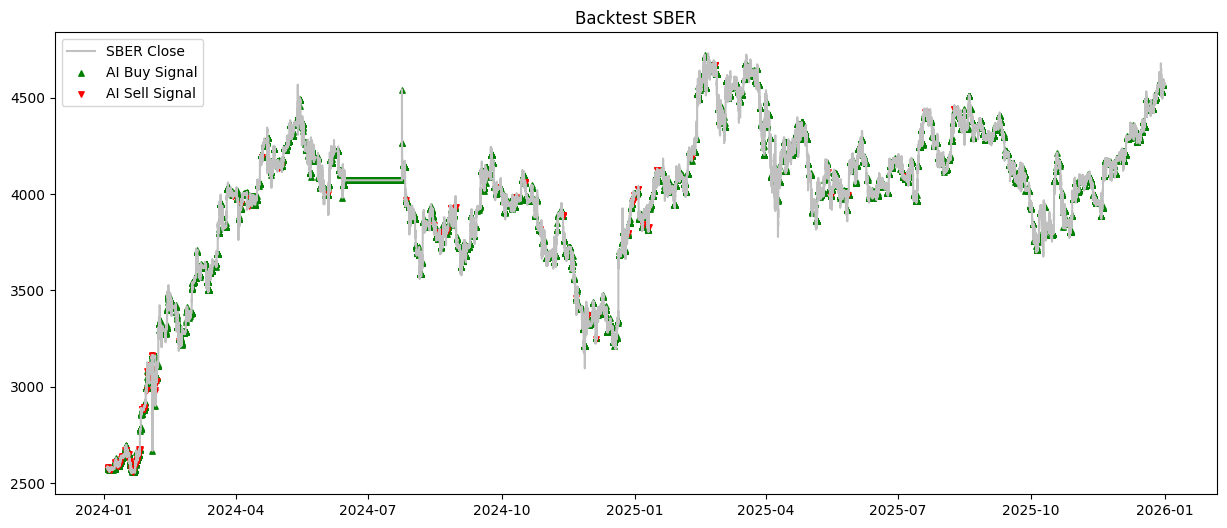

In [60]:
if not final_results.empty:
    # Визуализация 
    plt.figure(figsize=(15, 6))
    plt.plot(final_results['DateTime'], final_results['Price'], color='silver', label='SBER Close')
    
    # Сигналы
    up = final_results[final_results['Predicted'] == 1]
    down = final_results[final_results['Predicted'] == 2]
    
    plt.scatter(up['DateTime'], up['Price'], marker='^', color='green', s=15, label='AI Buy Signal')
    plt.scatter(down['DateTime'], down['Price'], marker='v', color='red', s=15, label='AI Sell Signal')
    
    plt.title(f"Backtest SBER")
    plt.legend()
    plt.show()

In [ ]:
def analyze_trades(df, commission=0.0003, rf_annual=0.15):
    """
    Анализ торговых сделок с расчётом holding period и ключевых метрик
    для диссертации (Profit Factor, RR, Sharpe, MDE, стат. значимость)
    
    Параметры:
        rf_annual — годовая безрисковая ставка (для Sharpe), например 0.15 = 15%
    """
    trades = []
    in_position = False
    entry_price = 0.0
    entry_date = None
    
    for i in range(len(df)):
        signal = df['Predicted'].iloc[i]
        price = df['Price'].iloc[i]
        date = df['DateTime'].iloc[i]
        
        if signal == 1 and not in_position:
            in_position = True
            entry_price = price
            entry_date = date
        
        elif (signal == 2 or i == len(df) - 1) and in_position:
            exit_price = price
            exit_date = date
            
            duration_delta = exit_date - entry_date
            duration_days = duration_delta.days
            duration_months = round(duration_days / 30.4375, 2)
            duration_years = round(duration_days / 365.25, 2)
            
            pnl = (exit_price - entry_price) / entry_price
            pnl_net = pnl - (commission * 2)          # комиссия за круг
            
            trades.append({
                'Entry Date': entry_date.strftime('%Y-%m-%d'),
                'Exit Date': exit_date.strftime('%Y-%m-%d'),
                'Entry Price': round(entry_price, 2),
                'Exit Price': round(exit_price, 2),
                'Profit %': round(pnl_net * 100, 2),
                'Duration Days': duration_days,
                'Duration Months': duration_months,
                'Duration Years': duration_years,
            })
            in_position = False
    
    trades_df = pd.DataFrame(trades)
    
    if trades_df.empty:
        print("Сделок не найдено.")
        return None
    
    # ────────────────────────────────────────────────
    # Основные метрики
    # ────────────────────────────────────────────────
    pnls = trades_df['Profit %'] / 100          # переводим обратно в доли
    n = len(pnls)
    
    win_rate = (pnls > 0).mean() * 100
    total_return = pnls.sum() * 100
    avg_trade = pnls.mean() * 100
    
    # Profit Factor
    gross_profit = pnls[pnls > 0].sum()
    gross_loss   = abs(pnls[pnls < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf
    
    # Average RR Ratio
    avg_win  = pnls[pnls > 0].mean() if (pnls > 0).any() else 0
    avg_loss = abs(pnls[pnls < 0].mean()) if (pnls < 0).any() else 0
    avg_rr   = avg_win / avg_loss if avg_loss != 0 else np.inf
    
    # Sharpe (приближённый на уровне сделок)
    # безрисковая ставка на одну сделку ≈ rf_annual / среднее количество сделок в год
    avg_duration_years = trades_df['Duration Years'].mean()
    if avg_duration_years > 0:
        trades_per_year = 1 / avg_duration_years
        rf_per_trade = rf_annual / trades_per_year
    else:
        rf_per_trade = 0
    
    excess_return = pnls.mean() - rf_per_trade
    std_pnl = pnls.std()
    sharpe = excess_return / std_pnl * np.sqrt(n) if std_pnl > 0 else 0
    
    # MDE (приближённая оценка минимально значимого эффекта, ~2.8 sigma / sqrt(n))
    mde = 2.8 * std_pnl / np.sqrt(n) if n > 1 else 0
    stat_significant = abs(pnls.mean()) > mde
    
    # Общий период
    total_days = (df['DateTime'].max() - df['DateTime'].min()).days
    total_months = round(total_days / 30.4375, 1)
    total_years = round(total_days / 365.25, 2)
    
    # ────────────────────────────────────────────────
    # Вывод в стиле научного отчёта
    # ────────────────────────────────────────────────
    print("═" * 70)
    print("ИТОГО ПО СТРАТЕГИИ")
    print("═" * 70)
    print(f"Всего сделок:              {n:>6d}")
    print(f"Win Rate:                  {win_rate:>6.1f} %")
    print(f"Общая доходность:          {total_return:>6.1f} %")
    print(f"Средняя сделка:            {avg_trade:>6.1f} %")
    print(f"Profit Factor:             {profit_factor:>6.2f}")
    print(f"Average RR Ratio:          {avg_rr:>6.2f}")
    print(f"Sharpe Ratio (по сделкам): {sharpe:>6.2f}")
    print(f"MDE (мин. значимый эффект):{mde*100:>6.2f} %")
    print(f"Статистическая значимость: {'ДА' if stat_significant else 'НЕТ (шум)'}")
    print("─" * 70)
    print(f"Период теста:              {total_days} дней ≈ {total_months} мес. ≈ {total_years:.2f} лет")
    print(f"Средний holding period:    {trades_df['Duration Days'].mean():.1f} дней "
          f"({trades_df['Duration Months'].mean():.2f} мес.)")
    print("═" * 70)
    
    return trades_df

report_df = analyze_trades(final_results)
display(report_df.head(20))

══════════════════════════════════════════════════════════════════════
ИТОГО ПО СТРАТЕГИИ (с расчётом holding period)
══════════════════════════════════════════════════════════════════════
Всего сделок:                 102
Win Rate:                    51.0 %
Общая доходность:            57.0 %
Средняя сделка:               0.6 %
Profit Factor:               1.79
Average RR Ratio:            1.73
Sharpe Ratio (по сделкам):   0.81
MDE (мин. значимый эффект):  1.02 %
Статистическая значимость: НЕТ (шум)
──────────────────────────────────────────────────────────────────────
Период теста:              728 дней ≈ 23.9 мес. ≈ 1.99 лет
Средний holding period:    6.4 дней (0.21 мес.)
══════════════════════════════════════════════════════════════════════


,Entry Date,Exit Date,Entry Price,Exit Price,Profit %,Duration Days,Duration Months,Duration Years
0,2024-01-03,2024-01-03,2582.0,2579.0,-0.18,0,0.00,0.00
1,2024-01-03,2024-01-04,2581.0,2573.5,-0.35,0,0.00,0.00
2,2024-01-04,2024-01-05,2570.0,2574.0,0.10,0,0.00,0.00
3,2024-01-05,2024-01-05,2573.0,2570.5,-0.16,0,0.00,0.00
4,2024-01-05,2024-01-05,2571.0,2570.0,-0.10,0,0.00,0.00
5,2024-01-05,2024-01-05,2574.0,2574.0,-0.06,0,0.00,0.00
6,2024-01-05,2024-01-08,2577.0,2602.5,0.93,2,0.07,0.01
7,2024-01-08,2024-01-09,2611.0,2593.5,-0.73,0,0.00,0.00
8,2024-01-09,2024-01-09,2595.5,2605.0,0.31,0,0.00,0.00
9,2024-01-09,2024-01-09,2608.0,2608.0,-0.06,0,0.00,0.00


In [ ]:
def analyze_strategy_performance(df, commission=0.0003, rf_rate=0.15, be_trigger=1.0):
    """
    Финальная версия для диссертации:
    - breakeven-логика (перенос в безубыток после +be_trigger%)
    - расчёт продолжительности каждой сделки
    - все метрики + статистическая значимость
    """
    trades = []
    in_pos = False
    entry_p, entry_d = 0.0, None
    is_breakeven = False
    
    for i in range(len(df)):
        sig = df['Predicted'].iloc[i]
        price = df['Price'].iloc[i]
        date = df['DateTime'].iloc[i]
        
        # ВХОД
        if sig == 1 and not in_pos:
            in_pos = True
            entry_p = price
            entry_d = date
            is_breakeven = False
            continue
        
        if not in_pos:
            continue
        
        # Текущая прибыль
        current_profit_pct = (price - entry_p) / entry_p * 100
        
        # Установка флага безубытка
        if not is_breakeven and current_profit_pct >= be_trigger:
            is_breakeven = True
        
        # Выход по безубытку
        if is_breakeven and current_profit_pct <= 0:
            pnl_net = - (commission * 2) * 100  # сразу в %
            duration = date - entry_d
            trades.append({
                'Entry Date': entry_d.strftime('%Y-%m-%d'),
                'Exit Date': date.strftime('%Y-%m-%d'),
                'Profit %': round(pnl_net, 2),
                'Type': 'Breakeven',
                'Duration Days': duration.days,
                'Duration Months': round(duration.days / 30.4375, 2)
            })
            in_pos = False
            continue
        
        # Обычный выход по сигналу
        if sig == 2 or i == len(df) - 1:
            pnl = (price - entry_p) / entry_p
            pnl_net = (pnl - commission * 2) * 100
            duration = date - entry_d
            trades.append({
                'Entry Date': entry_d.strftime('%Y-%m-%d'),
                'Exit Date': date.strftime('%Y-%m-%d'),
                'Profit %': round(pnl_net, 2),
                'Type': 'Signal',
                'Duration Days': duration.days,
                'Duration Months': round(duration.days / 30.4375, 2)
            })
            in_pos = False
    
    t_df = pd.DataFrame(trades)
    
    if t_df.empty:
        print("Сделок не найдено.")
        return None
    
    pnls = t_df['Profit %']
    win_rate = len(pnls[pnls > 0]) / len(pnls) * 100
    total_ret = pnls.sum()
    avg_pnl = pnls.mean()
    pf = pnls[pnls > 0].sum() / abs(pnls[pnls < 0].sum()) if any(pnls < 0) else np.inf
    rr = pnls[pnls > 0].mean() / abs(pnls[pnls < 0].mean()) if any(pnls < 0) else np.inf
    
    sharpe = ((pnls - (rf_rate / 252 * 100)).mean() / pnls.std() * np.sqrt(len(pnls))) if len(pnls) > 1 else 0
    mde = 2.8 * (pnls.std() / np.sqrt(len(pnls))) if len(pnls) > 1 else 0
    
    # Вывод
    print("="*60)
    print("ИТОГО ПО СТРАТЕГИИ (с безубытком + длительность)")
    print("="*60)
    print(f"Всего сделок:          {len(t_df)}")
    print(f"Win Rate:              {win_rate:.2f}%")
    print(f"Общая доходность:      {total_ret:.2f}%")
    print(f"Profit Factor:         {pf:.2f}")
    print(f"Avg RR Ratio:          {rr:.2f}")
    print(f"Sharpe Ratio:          {sharpe:.2f}")
    print(f"MDE (стат. порог):     {mde:.2f}%")
    print(f"Средняя длительность:  {t_df['Duration Days'].mean():.1f} дней "
          f"({t_df['Duration Months'].mean():.2f} мес.)")
    print(f"Стат. значимость:      {'ДА' if abs(avg_pnl) > mde else 'НЕТ (шум)'}")
    print("="*60)
    
    return t_df

report_df = analyze_strategy_performance(final_results, be_trigger=1.0)
display(report_df.head(20))

ИТОГО ПО СТРАТЕГИИ (с безубытком + длительность)
Всего сделок:          158
Win Rate:              33.54%
Общая доходность:      66.54%
Profit Factor:         2.02
Avg RR Ratio:          4.00
Sharpe Ratio:          1.54
MDE (стат. порог):     0.66%
Средняя длительность:  3.8 дней (0.13 мес.)
Стат. значимость:      НЕТ (шум)


,Entry Date,Exit Date,Profit %,Type,Duration Days,Duration Months
0,2024-01-03,2024-01-03,-0.18,Signal,0,0.00
1,2024-01-03,2024-01-04,-0.35,Signal,0,0.00
2,2024-01-04,2024-01-05,0.10,Signal,0,0.00
3,2024-01-05,2024-01-05,-0.16,Signal,0,0.00
4,2024-01-05,2024-01-05,-0.10,Signal,0,0.00
5,2024-01-05,2024-01-05,-0.06,Signal,0,0.00
6,2024-01-05,2024-01-08,0.93,Signal,2,0.07
7,2024-01-08,2024-01-09,-0.73,Signal,0,0.00
8,2024-01-09,2024-01-09,0.31,Signal,0,0.00
9,2024-01-09,2024-01-09,-0.06,Signal,0,0.00


In [76]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from scipy import stats

# ==============================
# PARAMETERS (можно менять)
# ==============================
HORIZON = 12
TRAIN_YEARS = 4
TEST_YEARS = 2
THRESHOLD = 0.001          # порог для входа в позицию
COMMISSION = 0.0003        # 0.03% round-trip комиссия
BARS_PER_YEAR = 252 * 78   # 5-минутные бары

# ==============================
# LOAD & PREPARE DATA
# ==============================
df = df_YDEX.copy()
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values("DateTime").reset_index(drop=True)

# ==============================
# FEATURES
# ==============================
def add_features(df):
    df = df.copy()
    close = df["Close"]
    volume = df["Volume"]

    df["return"] = close.pct_change()

    for lag in [1, 2, 3, 5, 10, 20]:
        df[f"ret_lag_{lag}"] = df["return"].shift(lag)
        df[f"vol_lag_{lag}"] = volume.shift(lag)

    df["volatility"] = df["return"].rolling(20).std()

    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(14).mean() / loss.rolling(14).mean()
    df["RSI"] = 100 - (100 / (1 + rs))

    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    df["MACD"] = ema12 - ema26

    df = df.replace([np.inf, -np.inf], np.nan)
    return df.dropna()

df = add_features(df)

# ==============================
# TARGET
# ==============================
df["target"] = df["Close"].pct_change(HORIZON).shift(-HORIZON)
df = df.dropna()

# ==============================
# TIME SPLIT (4 года обучение + 2 года тест)
# ==============================
start_date = df["DateTime"].min()
train_end = start_date + pd.DateOffset(years=TRAIN_YEARS)
test_end = train_end + pd.DateOffset(years=TEST_YEARS)

train_df = df[df["DateTime"] < train_end].copy()
test_df  = df[(df["DateTime"] >= train_end) & (df["DateTime"] < test_end)].copy()

print(f"Train period : {train_df['DateTime'].min().date()} — {train_df['DateTime'].max().date()}")
print(f"Test period  : {test_df['DateTime'].min().date()}  — {test_df['DateTime'].max().date()}")

# ==============================
# DATA PREPARATION
# ==============================
feature_cols = [c for c in df.columns if c not in ["DateTime", "target"]]

X_train = train_df[feature_cols]
y_train = train_df["target"]
X_test  = test_df[feature_cols]
y_test  = test_df["target"]
prices_test = test_df["Close"].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==============================
# MODELS
# ==============================
models = {
    "Ridge":    Ridge(alpha=1.0),
    "Lasso":    Lasso(alpha=0.0001),
    "LightGBM": LGBMRegressor(n_estimators=2000, learning_rate=0.005, max_depth=2, num_leaves=7, 
                              min_child_samples=100, colsample_bytree=0.4, reg_alpha=2, reg_lambda=5,
                              subsample=0.4, random_state=42, verbosity = -1),
    "CatBoost": CatBoostRegressor(iterations=2000, learning_rate=0.005, depth=2,
                                  verbose=0, random_state=42)
}

# ==============================
# MAIN LOOP
# ==============================
for name, model in models.items():
    print(f"\n{'='*20} {name} {'='*20}")
    
    # Обучение
    if name in ["Ridge", "Lasso"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # MAE / RMSE
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"MAE: {mae:.6f} | RMSE: {rmse:.6f}")

    # ==============================
    # BACKTEST (реальные сделки с горизонтом HORIZON)
    # ==============================
    trades = []
    equity = [1.0]
    position_open = False
    entry_price = 0.0
    entry_idx = 0

    for i in range(len(y_pred)):
        pred = y_pred[i]
        price = prices_test[i]

        # Закрываем позицию через HORIZON баров или в конце
        if position_open and (i >= entry_idx + HORIZON or i == len(y_pred)-1):
            exit_price = price
            ret = (exit_price - entry_price) / entry_price - COMMISSION * 2
            equity.append(equity[-1] * (1 + ret))
            
            trades.append({'Profit': ret, 'Profit_pct': ret * 100})
            position_open = False

        # Открываем позицию
        if not position_open:
            if pred > THRESHOLD:
                position_open = True
                entry_price = price * (1 + COMMISSION)
                entry_idx = i
            elif pred < -THRESHOLD:
                position_open = True
                entry_price = price * (1 - COMMISSION)
                entry_idx = i
        else:
            equity.append(equity[-1])

    equity = np.array(equity)
    returns_daily = np.diff(equity) / equity[:-1]

    # ==============================
    # МЕТРИКИ ПО СДЕЛКАМ
    # ==============================
    if trades:
        trades_df = pd.DataFrame(trades)
        pnls = trades_df['Profit']
        n = len(pnls)
        
        win_rate = (pnls > 0).mean() * 100
        total_return = (equity[-1] - 1) * 100
        avg_trade = pnls.mean() * 100
        
        gross_profit = pnls[pnls > 0].sum()
        gross_loss = abs(pnls[pnls < 0].sum())
        profit_factor = gross_profit / gross_loss if gross_loss != 0 else float('inf')
        
        avg_win = pnls[pnls > 0].mean() if (pnls > 0).any() else 0
        avg_loss = abs(pnls[pnls < 0].mean()) if (pnls < 0).any() else 0
        avg_rr = avg_win / avg_loss if avg_loss != 0 else float('inf')
        
        # Sharpe (по дневным изменениям equity)
        sharpe = (np.mean(returns_daily) / np.std(returns_daily) * np.sqrt(BARS_PER_YEAR)
                  if np.std(returns_daily) > 0 else 0)
        
        # MDE + статистическая значимость
        se = pnls.std() / np.sqrt(n) if n > 1 else 0
        mde = 2.8 * se * 100
        stat_sig = abs(pnls.mean() * 100) > mde
    else:
        n = 0
        win_rate = total_return = avg_trade = profit_factor = avg_rr = sharpe = mde = 0
        stat_sig = False

    # ==============================
    # КРАСИВЫЙ ВЫВОД (точно в твоём формате)
    # ==============================
    print("══════════════════════════════════════════════════════════════════════")
    print(f"ИТОГО ПО СТРАТЕГИИ → {name} (горизонт {HORIZON} баров)")
    print("══════════════════════════════════════════════════════════════════════")
    print(f"Всего сделок:          {n}")
    print(f"Win Rate:              {win_rate:.1f} %")
    print(f"Общая доходность:      {total_return:.1f} %")
    print(f"Средняя сделка:        {avg_trade:.1f} %")
    print(f"Profit Factor:         {profit_factor:.2f}")
    print(f"Average RR Ratio:      {avg_rr:.2f}")
    print(f"Sharpe Ratio:          {sharpe:.2f}")
    print(f"MDE (мин. значимый эффект): {mde:.2f} %")
    print(f"Статистическая значимость: {'ДА' if stat_sig else 'НЕТ (шум)'}")
    print("──────────────────────────────────────────────────────────────────────")
    print(f"Период теста:          {(test_df['DateTime'].max() - test_df['DateTime'].min()).days} дней "
          f"≈ {round((test_df['DateTime'].max() - test_df['DateTime'].min()).days/30.4375,1)} мес.")
    print(f"Средний holding period: {HORIZON} баров (фиксированный)")
    print("══════════════════════════════════════════════════════════════════════")

print("\nГотово! Все 4 модели обработаны.")

Train period : 2020-01-03 — 2024-01-03
Test period  : 2024-01-03  — 2025-12-31

==================== Ridge ====================
MAE: 0.002607 | RMSE: 0.004444
══════════════════════════════════════════════════════════════════════
ИТОГО ПО СТРАТЕГИИ → Ridge (горизонт 12 баров)
══════════════════════════════════════════════════════════════════════
Всего сделок:          2903
Win Rate:              47.7 %
Общая доходность:      -46.5 %
Средняя сделка:        -0.0 %
Profit Factor:         0.92
Average RR Ratio:      1.01
Sharpe Ratio:          -1.06
MDE (мин. значимый эффект): 0.04 %
Статистическая значимость: НЕТ (шум)
──────────────────────────────────────────────────────────────────────
Период теста:          728 дней ≈ 23.9 мес.
Средний holding period: 12 баров (фиксированный)
══════════════════════════════════════════════════════════════════════

==================== Lasso ====================
MAE: 0.002591 | RMSE: 0.004437
═════════════════════════════════════════════════════════════

In [139]:
# tickers_to_test = ['SBER', 'NVTK', 'TRNFP', 'SNGS', 'SNGSP', 'MGNT', 'ROSN', 'VTBR', 'TATN', 'GMKN', 'LKOH', 'MTSS', 'GAZP', 'HYDR', 'RTKM', 'ALRS', 'CHMF']
tickers_to_test = ['MGNT', 'VTBR', 'TATN', 'LKOH', 'YDEX', 'GLDRUB_TOM']

In [25]:
for i in tickers_to_test:
    df = pd.read_parquet('data/{i}_5min.parquet') 
    df = df[df['DateTime'] < '2026-01-01']
    df = fill_time_gaps(df)
    df = clean_market_data(df)
    
    X_all, y_all, dates_all, prices_all = create_tensors(df, window_size=WINDOW_SIZE, alpha=ALPHA)

    final_results = run_backtest_with_fine_tuning(df)

    report_df = analyze_strategy_performance(final_results)

NameError: name 'tickers_to_test' is not defined